Total rows: 74

Status:
status
OK        61
FAILED    13
Name: count, dtype: int64

Successful fits: 61
Valid fits: 61

Theta [mas]
count    61.000000
mean      1.956670
std       2.433060
min       0.045478
25%       0.469548
50%       1.201348
75%       2.202799
max      13.866754
Name: theta_mas, dtype: float64

Tb [K]
count    6.100000e+01
mean     5.717443e+11
std      1.093507e+12
min      6.017362e+08
25%      1.897261e+10
50%      1.239178e+11
75%      4.261161e+11
max      5.380202e+12
Name: Tb_K, dtype: float64


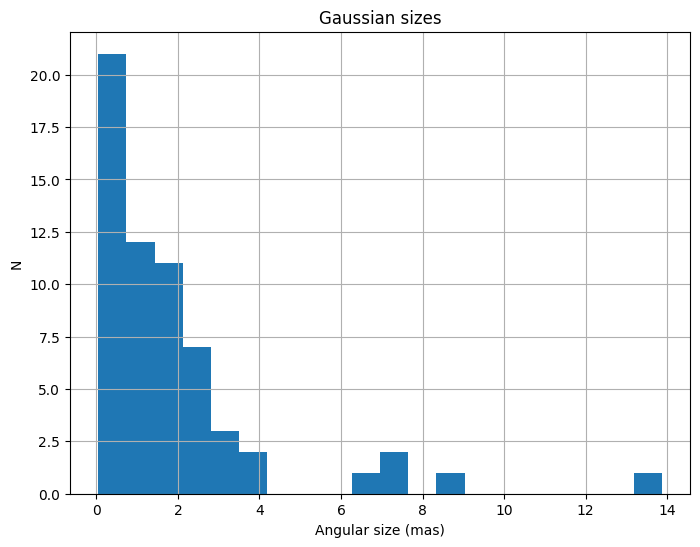

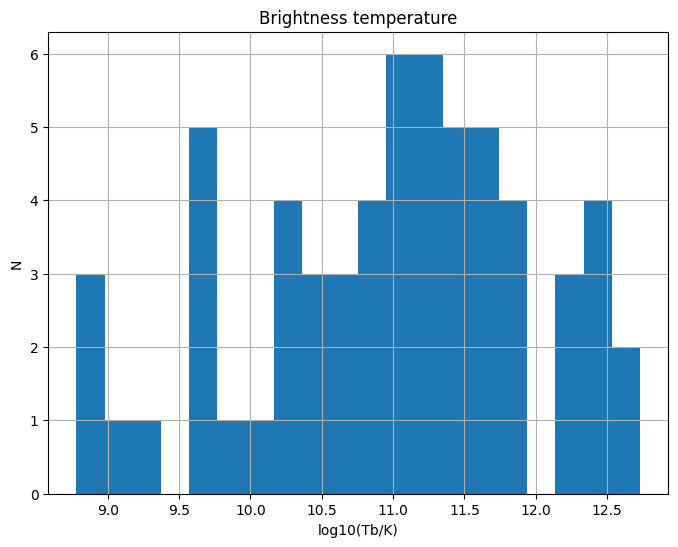

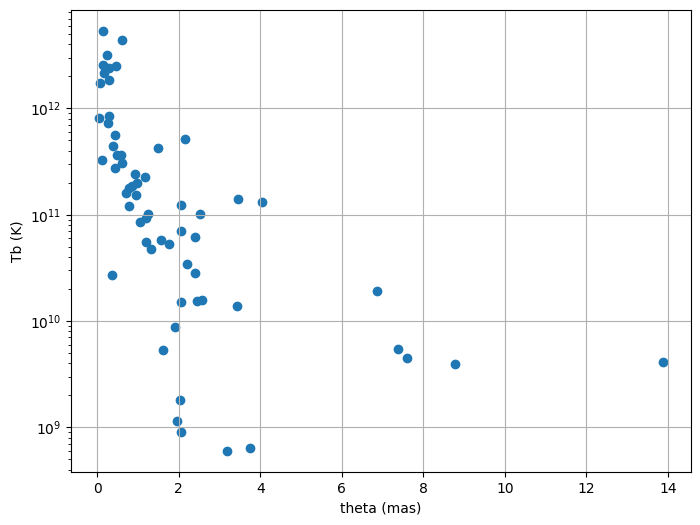


By band
      theta_mas          Tb_K
band                         
C      0.948731  1.690509e+11
K      1.910132  5.374860e+09
L      2.269186  1.274521e+11

By mode
             theta_mas          Tb_K
mode                                
GVLBI         2.460983  1.498207e+10
RADIOASTRON   0.972916  1.690509e+11

Smallest sizes


,session,date,band,theta_mas,theta_mas_err,Tb_K
39,RAKS12SY,20160329T010000,K,0.045478,4.887057,8.035636e+11
24,RAKS08JQ,20141214T080000,K,0.062611,6.044426,1.746803e+12
67,RAKS18OJ,20180306T110000,K,0.108546,6.726737,3.302747e+11
26,RAKS08TO,20150327T001000,C,0.138758,46.254241,5.380202e+12
9,RAES03RO,20130422T172000,C,0.157159,102.494663,2.543204e+12
17,RAKS01XX,20140403T010000,C,0.169777,102.787096,2.133224e+12
5,RAES03Q,20120405T170000,C,0.237506,2.742675,3.146771e+12
38,RAKS12SY,20160329T010000,C,0.279177,32.189478,7.281019e+11
4,RAES03P,20120404T183000,C,0.280257,8.311884,2.384453e+12
69,RAKS18OX,20180311T160000,C,0.286865,0.105887,1.854122e+12



Highest Tb


,session,date,band,theta_mas,theta_mas_err,Tb_K
26,RAKS08TO,20150327T001000,C,0.138758,46.254241,5.380202e+12
60,RAKS18EH,20171111T102000,L,0.613571,0.256446,4.426961e+12
5,RAES03Q,20120405T170000,C,0.237506,2.742675,3.146771e+12
9,RAES03RO,20130422T172000,C,0.157159,102.494663,2.543204e+12
45,RAKS12VB,20160423T140000,C,0.469548,0.194961,2.500089e+12
4,RAES03P,20120404T183000,C,0.280257,8.311884,2.384453e+12
17,RAKS01XX,20140403T010000,C,0.169777,102.787096,2.133224e+12
69,RAKS18OX,20180311T160000,C,0.286865,0.105887,1.854122e+12
24,RAKS08JQ,20141214T080000,K,0.062611,6.044426,1.746803e+12
31,RAKS12EV,20151106T090000,C,0.290877,26.099411,8.512122e+11


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "gaussian_fits/gaussian_fit_log.csv"

df = pd.read_csv(CSV)

print("Total rows:", len(df))

print("\nStatus:")
print(df["status"].value_counts())

# ----------------------------------------
# только успешные фиты
# ----------------------------------------

ok = df[df.status == "OK"].copy()

print("\nSuccessful fits:", len(ok))

# ----------------------------------------
# очистка
# ----------------------------------------

ok = ok.replace(
    [np.inf, -np.inf],
    np.nan
)

ok = ok.dropna(
    subset=[
        "theta_mas",
        "Tb_K"
    ]
)

print("Valid fits:", len(ok))

# ----------------------------------------
# статистика
# ----------------------------------------

print("\nTheta [mas]")

print(
    ok["theta_mas"].describe()
)

print("\nTb [K]")

print(
    ok["Tb_K"].describe()
)

# ----------------------------------------
# histogram theta
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    ok["theta_mas"],
    bins=20
)

plt.xlabel("Angular size (mas)")
plt.ylabel("N")

plt.title("Gaussian sizes")

plt.grid()

plt.show()

# ----------------------------------------
# histogram Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    np.log10(ok["Tb_K"]),
    bins=20
)

plt.xlabel("log10(Tb/K)")
plt.ylabel("N")

plt.title("Brightness temperature")

plt.grid()

plt.show()

# ----------------------------------------
# theta vs Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    ok["theta_mas"],
    ok["Tb_K"]
)

plt.yscale("log")

plt.xlabel("theta (mas)")
plt.ylabel("Tb (K)")

plt.grid()

plt.show()

# ----------------------------------------
# by band
# ----------------------------------------

print("\nBy band")

print(
    ok.groupby("band")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# by mode
# ----------------------------------------

print("\nBy mode")

print(
    ok.groupby("mode")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# compact epochs
# ----------------------------------------

print("\nSmallest sizes")

display(

    ok.sort_values(
        "theta_mas"
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",  # добавлено
            "Tb_K"
        ]
    ].head(20)

)

# ----------------------------------------
# hottest epochs
# ----------------------------------------

print("\nHighest Tb")

display(

    ok.sort_values(
        "Tb_K",
        ascending=False
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",
            "Tb_K"
        ]
    ].head(20)

)

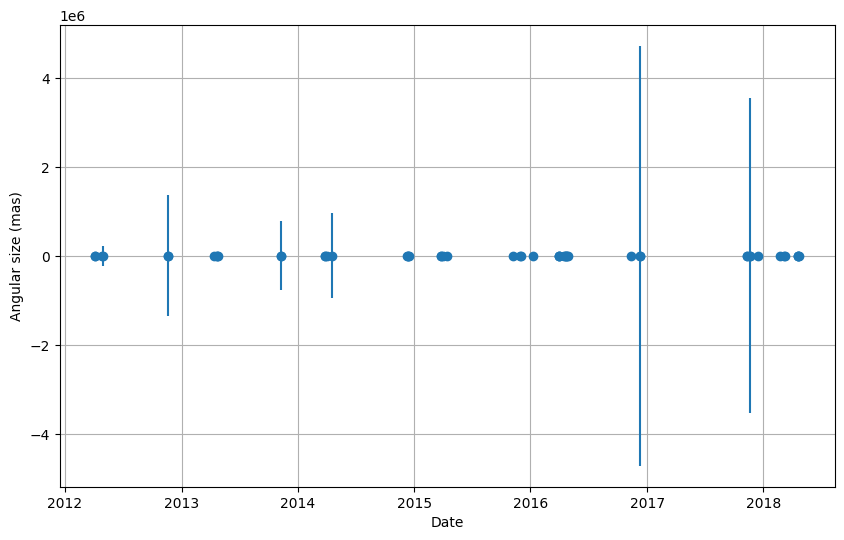

In [10]:
ra = ok[
    ok["mode"] == "RADIOASTRON"
]

plt.figure(figsize=(10,6))

plt.errorbar(
    pd.to_datetime(
        ra["date"].str[:8],  # берем только первые 8 символов (дату)
        format="%Y%m%d"
    ),
    ra["theta_mas"],
    yerr=ra["theta_mas_err"],
    fmt="o"
)

plt.xlabel("Date")
plt.ylabel("Angular size (mas)")
plt.grid()

plt.show()